# Covid-19 in South Korea

- To which region side of Seoul did virus spread the fastest and what might impacted it?
- Is treatment at home is effective as in hospital?
- In average how many people is infected by one person?

## Dataset import (format: alt + shift + F)

In [158]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from functions_sandbox import cleaner

path = r"D:\IT_projects\Turing_Colledge\Modul1\Sprint4\project"

case = pd.read_csv(path + r"\Case.csv")
patient_info = pd.read_csv(path + r"\PatientInfo.csv")
policy = pd.read_csv(path + r"\Policy.csv")
region = pd.read_csv(path + r"\Region.csv")
search_trend = pd.read_csv(path + r"\SearchTrend.csv")
seoul_floating = pd.read_csv(path + r"\SeoulFloating.csv")
time = pd.read_csv(path + r"\Time.csv")
time_age = pd.read_csv(path + r"\TimeAge.csv")
time_gender = pd.read_csv(path + r"\TimeGender.csv")
time_province = pd.read_csv(path + r"\TimeProvince.csv")
weather = pd.read_csv(path + r"\Weather.csv")

all_tables = [
    {"case": case},
    {"patient_info": patient_info},
    {"policy": policy},
    {"region": region},
    {"search_trend": search_trend},
    {"seoul_floating": seoul_floating},
    {"time": time},
    {"time_age": time_age},
    {"time_gender": time_gender},
    {"time_province": time_province},
    {"weather": weather},
]

### First look

In [159]:
shape_table = [(list(table.keys())[0], list(table.values())[0].shape) for table in all_tables]
for look in shape_table:
    print(look)

('case', (174, 8))
('patient_info', (5165, 14))
('policy', (61, 7))
('region', (244, 12))
('search_trend', (1642, 5))
('seoul_floating', (1084800, 7))
('time', (163, 7))
('time_age', (1089, 5))
('time_gender', (242, 5))
('time_province', (2771, 6))
('weather', (26271, 10))


In [160]:
weather.head(3)
#case: latitude, longitude to float;
#patient_info: many NaNs in various columns;
#policy: difficult to analise;
#region: very clean to analyse;
#search_trend: wrong dtype for date; nice table to analyse;
#seoul_floating: wrong dtype for date; what is fp_num?, birth_year?;
#time: should time be days?; dtype for date is wrong;
#time_age: wrong dtype for date; strange time; 
#time_gender: dtype for date; looks like random table;
#time_province: dtype for date; decent;
#weather: dtype for date; some of NaNs exists; interesting perspective to analyse;

,code,province,date,avg_temp,min_temp,max_temp,precipitation,max_wind_speed,most_wind_direction,avg_relative_humidity
0,10000,Seoul,2016-01-01,1.2,-3.3,4.0,0.0,3.5,90.0,73.0
1,11000,Busan,2016-01-01,5.3,1.1,10.9,0.0,7.4,340.0,52.1
2,12000,Daegu,2016-01-01,1.7,-4.0,8.0,0.0,3.7,270.0,70.5


In [227]:
time_province.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2771 entries, 0 to 2770
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   date       2771 non-null   object
 1   time       2771 non-null   int64 
 2   province   2771 non-null   object
 3   confirmed  2771 non-null   int64 
 4   released   2771 non-null   int64 
 5   deceased   2771 non-null   int64 
dtypes: int64(4), object(2)
memory usage: 130.0+ KB


### TimeProvince data preparation/cleaning

In [226]:
clean_time_province = cleaner(time_province, info=False)
clean_time_province["date"] = pd.to_datetime(clean_time_province["date"])
clean_time_province.sort_values(by="date", ascending=True, inplace=True)
clean_time_province["week"] = clean_time_province["date"].dt.isocalendar().week
clean_time_province.head(5)

,date,time,province,confirmed,released,deceased,week
0,2020-01-20,16,Seoul,0,0,0,4
16,2020-01-20,16,Jeju-do,0,0,0,4
15,2020-01-20,16,Gyeongsangnam-do,0,0,0,4
14,2020-01-20,16,Gyeongsangbuk-do,0,0,0,4
13,2020-01-20,16,Jeollanam-do,0,0,0,4


### TimeAge data preparation/cleaning

In [224]:
clean_time_age = cleaner(time_age, info=False)
clean_time_age.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1089 entries, 0 to 1088
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   date       1089 non-null   object
 1   time       1089 non-null   int64 
 2   age        1089 non-null   object
 3   confirmed  1089 non-null   int64 
 4   deceased   1089 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 42.7+ KB


In [233]:
clean_time_age["date"] = pd.to_datetime(clean_time_age["date"])
clean_time_age.sort_values(by="date", ascending=True, inplace=True)
clean_time_age

,date,time,age,confirmed,deceased
0,2020-03-02,0,0s,32,0
1,2020-03-02,0,10s,169,0
2,2020-03-02,0,20s,1235,0
3,2020-03-02,0,30s,506,1
4,2020-03-02,0,40s,633,1
...,...,...,...,...,...
1081,2020-06-30,0,10s,708,0
1082,2020-06-30,0,20s,3362,0
1083,2020-06-30,0,30s,1496,2
1084,2020-06-30,0,40s,1681,3


### TimeGender data preparation/cleaning

In [230]:
clean_time_gender = cleaner(time_gender, info=False)
clean_time_gender.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242 entries, 0 to 241
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   date       242 non-null    object
 1   time       242 non-null    int64 
 2   sex        242 non-null    object
 3   confirmed  242 non-null    int64 
 4   deceased   242 non-null    int64 
dtypes: int64(3), object(2)
memory usage: 9.6+ KB


In [231]:
clean_time_gender["date"] = pd.to_datetime(clean_time_gender["date"])
clean_time_gender.sort_values(by="date", ascending=True, inplace=True)
clean_time_gender

,date,time,sex,confirmed,deceased
0,2020-03-02,0,male,1591,13
1,2020-03-02,0,female,2621,9
2,2020-03-03,0,male,1810,16
3,2020-03-03,0,female,3002,12
4,2020-03-04,0,male,1996,20
...,...,...,...,...,...
237,2020-06-28,0,female,7265,131
238,2020-06-29,0,male,5470,151
239,2020-06-29,0,female,7287,131
240,2020-06-30,0,male,5495,151


## EDA (Exploratory Data Analysis)

### Virus spreading in provinces

In [ ]:
unique_provinces = clean_time_province["province"].unique()
grouped_provinces = (
    clean_time_province.groupby("province")
    .agg({"confirmed": "sum", "released": "sum", "deceased": "sum"})
    .sort_values(by="confirmed", ascending=False)
    .reset_index()
)
date_start = clean_time_province["date"].min()
date_end = clean_time_province["date"].max()

print(f"There are {len(unique_provinces)} unique provinces\n")
print(f"Date when tracking was started: {date_start}")
print(f"Date when tracking was ended: {date_end}\n")
print(grouped_provinces)

In [ ]:
top_names = list(grouped_provinces["province"][:5])
top_five = clean_time_province[clean_time_province["province"].isin(top_names)]
top_five_df = top_five.copy()
grouped = top_five_df.groupby("province")["confirmed"].cumsum()
top_five_df["confirmed_cumsum"] = grouped
top_five_df

In [ ]:
sns.set_style("darkgrid")
sns.set_context("notebook")
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=top_five_df, x="date", y=top_five_df["confirmed_cumsum"], hue="province")

plt.xlabel("Weeks", fontweight="bold")
plt.ylabel("Confirmed cases", fontweight="bold")
plt.title("Cumulative confirmed cases of Covid-19 on top 5 provinces", fontweight="bold", fontsize=16)

plt.show()

### TimeAge spreading

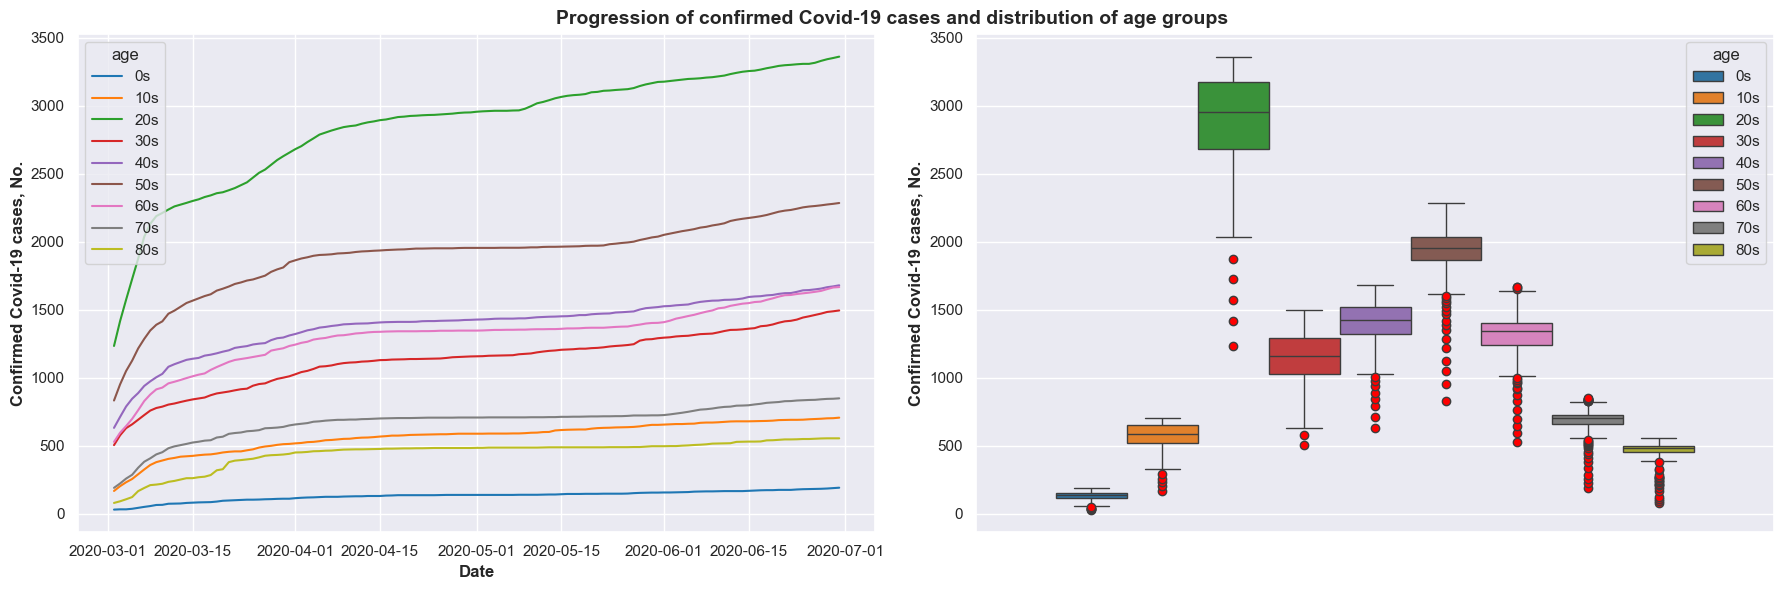

In [285]:
sns.set_style("darkgrid")
sns.set_context("notebook")
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

sns.lineplot(data=clean_time_age, x="date", y="confirmed", hue="age", ax=ax[0])
ax[0].set_xlabel("Date", fontweight="bold")
ax[0].set_ylabel("Confirmed Covid-19 cases, No.", fontweight="bold")

sns.boxplot(data=clean_time_age, y="confirmed", hue="age", ax=ax[1], showfliers=True, flierprops=dict(markerfacecolor="red", marker="o"))
ax[1].set_ylabel("Confirmed Covid-19 cases, No.", fontweight="bold")

plt.tight_layout()
plt.subplots_adjust(top=0.94)
fig.suptitle(
    "Progression of confirmed Covid-19 cases and distribution of age groups",
    size=14,
    fontweight="bold",
    ha="center"
)

plt.show()